In [34]:
import os
import zipfile
import torch
import pandas as pd
import numpy as np
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from collections import OrderedDict
from tqdm.notebook import tqdm

In [35]:
dataset = ImageFolder("/content/drive/MyDrive/csc420/Task5")
print(len(dataset))
print(len(dataset.classes))

1292
2


In [5]:
# random delete pictures in SDD dataset to make two datasets have same number of cases
import os
import random
dir = "/content/drive/MyDrive/csc420/Task5"

# Define SDD and DBI as strings
SDD = "SDD"
DBI = "DBI"

files_SDD = os.listdir(os.path.join(dir, SDD)) # Use os.path.join to create paths
files_DBI = os.listdir(os.path.join(dir, DBI))
print(files_SDD)
no = len(files_SDD)
to_delete = no - len(files_DBI)

l = list(range(0,no,1))
random.shuffle(l)
print(l)
delete_files = l[0:to_delete]

for i in range(len(delete_files)):
  # Use os.path.join to create paths
  os.remove(os.path.join(dir, SDD, files_SDD[i]))

['n02106166_5057.jpg', 'n02106166_470.jpg', 'n02106166_3515.jpg', 'n02106166_3882.jpg', 'n02106166_4957.jpg', 'n02106166_615.jpg', 'n02106166_4966.jpg', 'n02106166_59.jpg', 'n02106166_401.jpg', 'n02106166_6415.jpg', 'n02106166_5.jpg', 'n02106166_6084.jpg', 'n02106166_3996.jpg', 'n02106166_4107.jpg', 'n02106166_4412.jpg', 'n02106166_3865.jpg', 'n02106166_459.jpg', 'n02106166_5818.jpg', 'n02106166_3850.jpg', 'n02106166_4450.jpg', 'n02106166_476.jpg', 'n02106166_5097.jpg', 'n02106166_4753.jpg', 'n02106166_654.jpg', 'n02106166_5073.jpg', 'n02106166_943.jpg', 'n02106166_416.jpg', 'n02106166_4733.jpg', 'n02106166_402.jpg', 'n02106166_361.jpg', 'n02106166_5869.jpg', 'n02106166_549.jpg', 'n02106166_930.jpg', 'n02106166_5047.jpg', 'n02106166_678.jpg', 'n02106166_4625.jpg', 'n02106166_5607.jpg', 'n02107683_3694.jpg', 'n02107683_3655.jpg', 'n02107683_1400.jpg', 'n02107683_1536.jpg', 'n02107683_3351.jpg', 'n02107683_1417.jpg', 'n02107683_4411.jpg', 'n02107683_3034.jpg', 'n02107683_3988.jpg', 'n021

In [36]:
dataset = ImageFolder("/content/drive/MyDrive/csc420/Task5")
print(len(dataset))
print(len(dataset.classes))

1292
2


In [37]:
types = []

for n in dataset.classes:
    types.append(n)

types


['DBI', 'SDD']

In [39]:

test_pct = 0.4
test_size = int(len(dataset)*test_pct)
dataset_size = len(dataset) - test_size

train_size = len(dataset) - test_size

train_size, test_size

(776, 516)

In [40]:
train_ds, test_ds = random_split(dataset, [train_size, test_size])
len(train_ds), len(test_ds)

(776, 516)

In [41]:
class DogBreedDataset(Dataset):

    def __init__(self, ds, transform=None):
        self.ds = ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]
        if self.transform:
            img = self.transform(img)
            return img, label

In [42]:
imagenet_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_transform = transforms.Compose([
#    transforms.Resize((224, 224)),
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
#    transforms.Normalize(*imagenet_stats, inplace=True)

])


val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
#    transforms.Normalize(*imagenet_stats, inplace=True)
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
#    transforms.Normalize(*imagenet_stats, inplace=True)
])

In [43]:
train_dataset = DogBreedDataset(train_ds, train_transform)

test_dataset = DogBreedDataset(test_ds, test_transform)



In [66]:
batch_size = 32

# Create DataLoaders
train_dl = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_dataset, batch_size*2, num_workers=2, pin_memory=True)

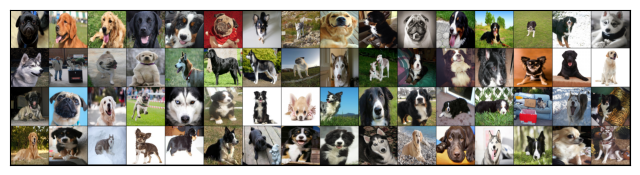

In [90]:
def show_batch(dl):
    for img, lb in dl:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(img.cpu(), nrow=16).permute(1,2,0))
        break
show_batch(test_dl)

In [46]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [47]:
class ImageClassificationBase(nn.Module):
    # training step
    def training_step(self, batch):
        img, targets = batch
        out = self(img)
        loss = F.nll_loss(out, targets)
        return loss

    # validation step
    def validation_step(self, batch):
        img, targets = batch
        out = self(img)
        loss = F.nll_loss(out, targets)
        acc = accuracy(out, targets)
        return {'val_acc':acc.detach(), 'val_loss':loss.detach()}

    # validation epoch end
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss':epoch_loss.item(), 'val_acc':epoch_acc.item()}

    # print result end epoch
    def epoch_end(self, epoch, result):
        print("Epoch [{}] : train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result["train_loss"], result["val_loss"], result["val_acc"]))


In [48]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(d, device) for d in data]
    else:
        return data.to(device, non_blocking=True)

In [49]:
class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __len__(self):
        return len(self.dl)

    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch, self.device)

In [50]:
from tqdm.notebook import tqdm

In [78]:
def get_lr(optimizer):
      for param_group in optimizer.param_groups:
        return param_group['lr']


def fit_one_cycle(epochs, max_lr, model, train_loader, test_loader, weight_decay=0, grad_clip=None, opt_func = torch.optim.Adam):
    torch.cuda.empty_cache()
    history = []
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    # set up one cycle lr scheduler
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_loader))

    for epoch in range(epochs):

        # Training phase
        model.train()
        train_losses = []
        lrs = []
        for batch in tqdm(train_loader):
            loss = model.training_step(batch)
            train_losses.append(loss)

            # calculates gradients
            loss.backward()

            # check gradient clipping
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            # perform gradient descent and modifies the weights
            optimizer.step()

            # reset the gradients
            optimizer.zero_grad()

            # record and update lr
            lrs.append(get_lr(optimizer))

            # modifies the lr value
            sched.step()

        # Validation phase
        result = evaluate(model, test_loader, train_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)


    return history



@torch.no_grad()
def evaluate(model, test_loader, train_loader):
    # I added train accuracy here
    model.eval()
    train_outputs = [model.validation_step(batch) for batch in train_loader]
    test_outputs = [model.validation_step(batch) for batch in test_loader]

    output_train = model.validation_epoch_end(train_outputs)
    output_test = model.validation_epoch_end(test_outputs)
    output = output_train
    output['test_acc'] = output_test['val_acc']
    return output

In [52]:
device = get_default_device()

In [73]:
class DogBreedDogBreedResNeXt50PretrainedPretrained(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.resnext50_32x4d(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 2),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [74]:
resneXt50_pretrained_model = DogBreedResNeXt50Pretrained()
resneXt50_pretrained_model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 156MB/s]


DogBreedResNeXt50Pretrained(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
       

In [69]:
num_epochs = 10
opt_func = torch.optim.SGD

max_lr = 0.012
grad_clip = 0.1
weight_decay = 1e-4

In [75]:
train_dl = DeviceDataLoader(train_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
resneXt50_pretrained_model = to_device(resneXt50_pretrained_model, device);

In [79]:
evaluate(resneXt50_pretrained_model, train_dl, test_dl)

{'val_loss': 0.8567268252372742,
 'val_acc': 0.4930555522441864,
 'test_acc': 0.5087500214576721}

In [80]:
history = fit_one_cycle(num_epochs, max_lr, resneXt50_pretrained_model, train_dl, test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [0] : train_loss: 0.5798, val_loss: 0.5126, val_acc: 0.7900


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [1] : train_loss: 0.3110, val_loss: 0.3615, val_acc: 0.8725


  0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 0.0875, val_loss: 0.0339, val_acc: 0.9850


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [8] : train_loss: 0.0705, val_loss: 0.0288, val_acc: 0.9912


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [9] : train_loss: 0.0351, val_loss: 0.0230, val_acc: 0.9937


In [81]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# Set the model to evaluation mode
def scores(model, dbi_test_dl):
  """
  """
  model.eval()

# Initialize empty lists to store predictions and true labels
  y_pred = []
  y_true = []

  # Iterate over batches in the test dataloader
  for images, labels in dbi_test_dl:
      # Move images and labels to device (GPU/CPU)
      images = images.to(device)
      labels = labels.to(device)

      # Disable gradient computation to speed up inference
      with torch.no_grad():
          # Make predictions
          outputs = model(images)
          # Get predicted labels for each image in the batch
          _, predicted = torch.max(outputs.data, 1)

      # Append predicted and true labels to their respective lists
      y_pred.extend(predicted.cpu().numpy())
      y_true.extend(labels.cpu().numpy())

  # Print classification report and accuracy score
  print(classification_report(y_true, y_pred))
  print("Accuracy:", accuracy_score(y_true, y_pred))
  return accuracy_score(y_true, y_pred)

In [82]:
accuracy_resneXt50 = scores(resneXt50_pretrained_model, test_dl)
print("Accuracy of resneXt5:", accuracy_resneXt50)

              precision    recall  f1-score   support

           0       0.91      0.84      0.87       262
           1       0.84      0.91      0.88       254

    accuracy                           0.87       516
   macro avg       0.88      0.87      0.87       516
weighted avg       0.88      0.87      0.87       516

Accuracy: 0.874031007751938
Accuracy of resneXt5: 0.874031007751938


In [88]:
train_loss = []
test_acc = []
train_acc = []
time = list(range(len(history)))
for i in range(len(time)):
  history[i]['train_acc'] = history[i]['val_acc']
for h in history:
    train_loss.append(h['train_loss'])
    test_acc.append(h['test_acc'])
    train_acc.append(h['train_acc'])


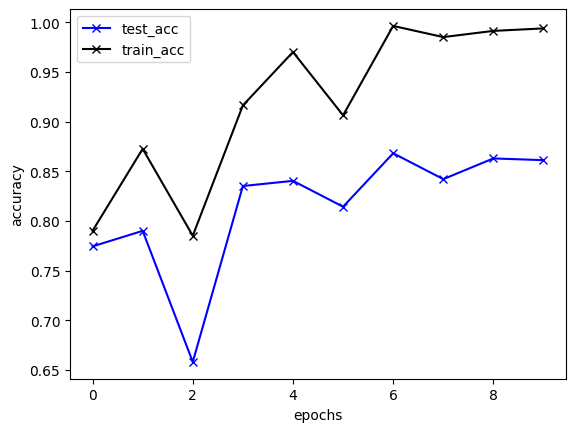

<Figure size 640x480 with 0 Axes>

In [89]:
plt.plot(time, test_acc, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('resneXt50_pretrained.png')

**DenseNet121**

In [91]:
class DogBreedDenseNet121Pretrained(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.densenet121(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.classifier.in_features
        self.network.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

In [92]:
densenet121_pretrained_model = DogBreedDenseNet121Pretrained()
densenet121_pretrained_model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DogBreedDenseNet121Pretrained(
  (network): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, e

In [93]:
num_epochs = 10
opt_func = torch.optim.SGD

max_lr = 0.012
grad_clip = 0.1
weight_decay = 1e-4

In [94]:
train_dl = DeviceDataLoader(train_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
densenet121_pretrained_model = to_device(densenet121_pretrained_model, device);

In [95]:
evaluate(densenet121_pretrained_model, train_dl, test_dl)

{'val_loss': 2.1756880283355713,
 'val_acc': 0.02604166604578495,
 'test_acc': 0.011250000447034836}

In [96]:
history = fit_one_cycle(num_epochs, max_lr, densenet121_pretrained_model, train_dl, test_dl, weight_decay, grad_clip, opt_func)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [0] : train_loss: 1.0455, val_loss: 0.5721, val_acc: 0.7138


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [1] : train_loss: 0.4141, val_loss: 0.2905, val_acc: 0.8763


  0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch [7] : train_loss: 0.1003, val_loss: 0.0944, val_acc: 0.9638


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [8] : train_loss: 0.0827, val_loss: 0.0258, val_acc: 0.9950


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [9] : train_loss: 0.0478, val_loss: 0.0228, val_acc: 0.9962


In [97]:
accuracy_densenet121 = scores(densenet121_pretrained_model, test_dl)
print("Accuracy of Densenet121:", accuracy_densenet121)

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       262
           1       0.87      0.91      0.89       254

    accuracy                           0.89       516
   macro avg       0.89      0.89      0.89       516
weighted avg       0.89      0.89      0.89       516

Accuracy: 0.8895348837209303
Accuracy of Densenet121: 0.8895348837209303


In [98]:
train_loss = []
test_acc = []
train_acc = []
time = list(range(len(history)))
for i in range(len(time)):
  history[i]['train_acc'] = history[i]['val_acc']
for h in history:
    train_loss.append(h['train_loss'])
    test_acc.append(h['test_acc'])
    train_acc.append(h['train_acc'])


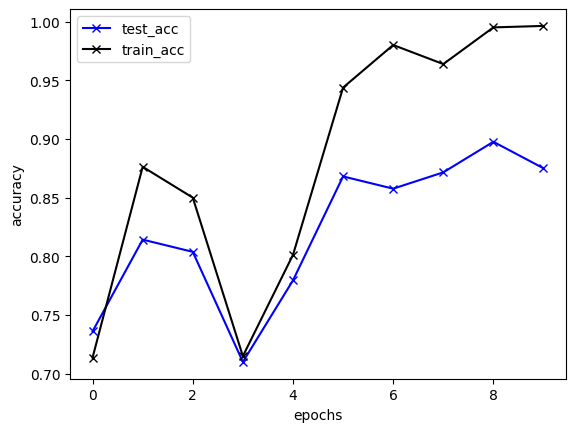

<Figure size 640x480 with 0 Axes>

In [99]:
plt.plot(time, test_acc, c='blue', label='test_acc', marker='x')
plt.plot(time, train_acc, c='black', label='train_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.savefig('densenet121_pretrained.png')